## Librerias

In [189]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns  

## Carga datos clean

In [190]:
df_ops = pd.read_csv('C:\\Users\\Usuario\\ProjecteData\\Equip_25\\Data\\clean_data_24-03-2026.csv', parse_dates=['insert_date'])

# inventario activo
df_active = df_ops.loc[df_ops["has_availability"] == True, ["apartment_id","host_id", "room_type", "bedrooms", "bathrooms", "beds", "accommodates", 
                                                            "availability_30", "availability_60", "availability_90", "availability_365", "minimum_nights", 
                                                            "maximum_nights", "city",
                                                            "insert_date", "is_instant_bookable", "price", "price_missing"]].copy()

df_active.info()
df_active.head()

<class 'pandas.core.frame.DataFrame'>
Index: 9116 entries, 0 to 9649
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   apartment_id         9116 non-null   int64         
 1   host_id              9116 non-null   int64         
 2   room_type            9116 non-null   object        
 3   bedrooms             9048 non-null   float64       
 4   bathrooms            9043 non-null   float64       
 5   beds                 9072 non-null   float64       
 6   accommodates         9116 non-null   int64         
 7   availability_30      9116 non-null   int64         
 8   availability_60      9116 non-null   int64         
 9   availability_90      9116 non-null   int64         
 10  availability_365     9116 non-null   int64         
 11  minimum_nights       9116 non-null   int64         
 12  maximum_nights       9116 non-null   int64         
 13  city                 9116 non-null   o

,apartment_id,host_id,room_type,bedrooms,bathrooms,beds,accommodates,availability_30,availability_60,availability_90,availability_365,minimum_nights,maximum_nights,city,insert_date,is_instant_bookable,price,price_missing
0,11964,45553,Private room,1.0,2.0,1.0,2,7,20,40,130,3,365,Malaga,2018-07-31,False,400.0,False
1,21853,83531,Private room,1.0,1.0,1.0,1,0,0,0,162,4,40,Madrid,2020-01-10,False,170.0,False
2,32347,139939,Entire home/apt,2.0,1.0,2.0,4,26,31,31,270,2,120,Sevilla,2019-07-29,True,990.0,False
3,35379,152232,Private room,1.0,2.0,1.0,2,9,23,49,300,2,730,Barcelona,2020-01-10,True,400.0,False
4,35801,153805,Private room,2.0,1.0,5.0,5,0,19,49,312,1,180,Girona,2019-02-19,False,900.0,False


In [191]:
# host_counts = df_active.groupby("host_id")["apartment_id"].nunique()

# host_counts.describe()
# host_counts.value_counts().head(10)

#### Definición de métricas
- Disponibilidad: Normalizas horizontes temporales, permite comparabilidad, availability_30 captura demanda reciente
- Capacidad total: bedrooms no captura sofás cama, etc., accommodates es la capacidad real de demanda
- Densidad: listings sobrecargados vs cómodos
- Tamaño categorizado (para interpretación): mejora la lectura de resultados

In [192]:
# precio en nulos
df_active['price_filled'] = df_active['price'].fillna(df_active['price'].median())

# precio por persona
df_active['price_per_guest'] = df_active['price_filled'] / df_active['accommodates']

# LOG TRANSFORM -- para manejar la asimetría del precio por persona por existencia de listings con precios muy altos
df_active['log_price_per_guest'] = np.log(df_active['price_per_guest'])

# disponibilidad
df_active['availability_30_pct'] = df_active['availability_30'] / 30
df_active['availability_60_pct'] = df_active['availability_60'] / 60
df_active['availability_90_pct'] = df_active['availability_90'] / 90
df_active['availability_365_pct'] = df_active['availability_365'] / 365

available_cols = ["availability_30_pct", "availability_60_pct", "availability_90_pct", "availability_365_pct"]

# habitaciones
df_active['bedrooms'] = df_active['bedrooms'].fillna(0)
# baños
df_active['bathrooms'] = pd.to_numeric(df_active['bathrooms'], errors='coerce')
# camas
df_active['beds'] = df_active['beds'].fillna(0)

# capacidad total
df_active['capacity'] = df_active['accommodates']

# densidad
df_active['bed_density'] = df_active['beds'] / df_active['accommodates']

# tamaño categorizado
df_active['size_segment'] = pd.cut(
    df_active['accommodates'],
    bins=[0,2,4,6,10,20],
    labels=['1-2','3-4','5-6','7-10','10+']
)

# bed density
df_active['bed_density'] = df_active['beds'] / df_active['accommodates']

In [193]:
columns_needed = [
    'availability_30_pct',
    'capacity',
    'bed_density',
    'bathrooms',
    'price_per_guest',
    'log_price_per_guest',
    'city',
    'room_type'
]

df_model = df_active[columns_needed].dropna().copy()

## Análisis / visualizaciones
Com afecta el nombre d'habitacions, banys i llits
disponibles a la disponibilitat mitjana dels allotjaments? Difereix entre ciutats?

In [194]:
# Media simple
df_active.groupby('capacity')['availability_30_pct'].mean()

capacity
1     0.417091
2     0.406495
3     0.412507
4     0.440302
5     0.448914
6     0.453893
7     0.428358
8     0.475957
9     0.463370
10    0.486333
11    0.510000
12    0.556180
13    0.814286
14    0.541667
15    0.700000
16    0.582963
18    1.000000
19    1.000000
20    0.000000
24    0.000000
29    0.166667
Name: availability_30_pct, dtype: float64

In [195]:
# Por ciudad
df_active.groupby(['city','size_segment'])['availability_30_pct'].mean()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_31964\1453132624.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_active.groupby(['city','size_segment'])['availability_30_pct'].mean()


city       size_segment
Barcelona  1-2             0.402379
           3-4             0.403816
           5-6             0.429074
           7-10            0.442450
           10+             0.560000
Girona     1-2             0.503672
           3-4             0.496549
           5-6             0.498410
           7-10            0.465820
           10+             0.597484
Madrid     1-2             0.367975
           3-4             0.386197
           5-6             0.422690
           7-10            0.489333
           10+             0.633333
Malaga     1-2             0.387816
           3-4             0.452713
           5-6             0.405051
           7-10            0.427928
           10+             0.700000
Mallorca   1-2             0.505000
           3-4             0.418868
           5-6             0.446195
           7-10            0.476368
           10+             0.517808
Menorca    1-2             0.441667
           3-4             0.503876
    

In [196]:
df_active[['bedrooms','beds','accommodates']].corr()

,bedrooms,beds,accommodates
bedrooms,1.000000,0.774495,0.796162
beds,0.774495,1.000000,0.861774
accommodates,0.796162,0.861774,1.000000


#### Test estadístico
Modelo de regresión lineal múltiple
- Variable dependiente: availability_30_pct
- Variables independientes: bathrooms, bed_density, capacity, city, room_type, price_per_guest

In [197]:
# 1. Variables base
df_model = df_model[df_model['capacity'] < 15]
df_model = df_model[df_model['bed_density'] < 2]

# 3. Seleccionar variables
X = df_model[['capacity', 'bed_density', 'bathrooms', 'city', 'room_type','log_price_per_guest']]
y = df_model['availability_30_pct']

# 4. Crear dummies
X = pd.get_dummies(X, columns=['city', 'room_type'], drop_first=True)

# 5. Convertir a numérico
X = X.astype(float)

# 6. Limpiar NaNs
df_model_final = pd.concat([X, y], axis=1).dropna()

X = df_model_final.drop(columns=['availability_30_pct'])
y = df_model_final['availability_30_pct']

# 7. Añadir constante
X = sm.add_constant(X)

# 8. Modelo
model = sm.OLS(y, X).fit()

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     availability_30_pct   R-squared:                       0.020
Model:                             OLS   Adj. R-squared:                  0.018
Method:                  Least Squares   F-statistic:                     12.73
Date:                 Wed, 25 Mar 2026   Prob (F-statistic):           3.22e-30
Time:                         12:34:29   Log-Likelihood:                -4324.9
No. Observations:                 8945   AIC:                             8680.
Df Residuals:                     8930   BIC:                             8786.
Df Model:                           14                                         
Covariance Type:             nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const             

In [198]:
# 1. Variables base
df_model = df_model[df_model['capacity'] < 15]
df_model = df_model[df_model['bed_density'] < 2]

# 3. Seleccionar variables
X = df_model[['capacity', 'city', 'room_type','log_price_per_guest']]
y = df_model['availability_30_pct']

# 4. Crear dummies
X = pd.get_dummies(X, columns=['city', 'room_type'], drop_first=True)

# 5. Convertir a numérico
X = X.astype(float)

# 6. Limpiar NaNs
df_model_final = pd.concat([X, y], axis=1).dropna()

X = df_model_final.drop(columns=['availability_30_pct'])
y = df_model_final['availability_30_pct']

# 7. Añadir constante
X = sm.add_constant(X)

# 8. Modelo
model = sm.OLS(y, X).fit()

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     availability_30_pct   R-squared:                       0.019
Model:                             OLS   Adj. R-squared:                  0.018
Method:                  Least Squares   F-statistic:                     14.75
Date:                 Wed, 25 Mar 2026   Prob (F-statistic):           3.77e-31
Time:                         12:34:29   Log-Likelihood:                -4325.5
No. Observations:                 8945   AIC:                             8677.
Df Residuals:                     8932   BIC:                             8769.
Df Model:                           12                                         
Covariance Type:             nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const             

## Resultados / archivos generados

<Axes: xlabel='size_segment', ylabel='availability_30_pct'>

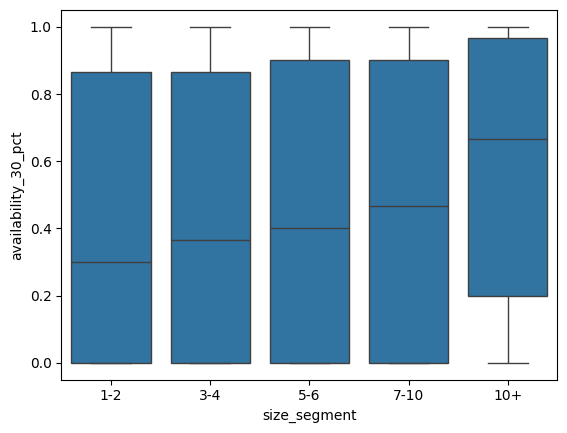

In [199]:
sns.boxplot(x='size_segment', y='availability_30_pct', data=df_active)

<Axes: xlabel='city', ylabel='availability_30_pct'>

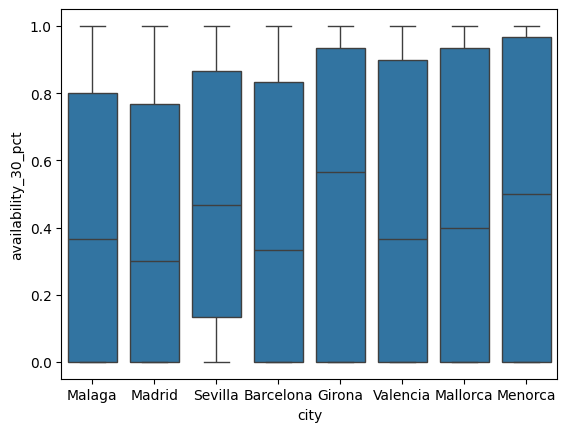

In [200]:
sns.boxplot(x='city', y='availability_30_pct', data=df_active)

<Axes: xlabel='price_per_guest', ylabel='Count'>

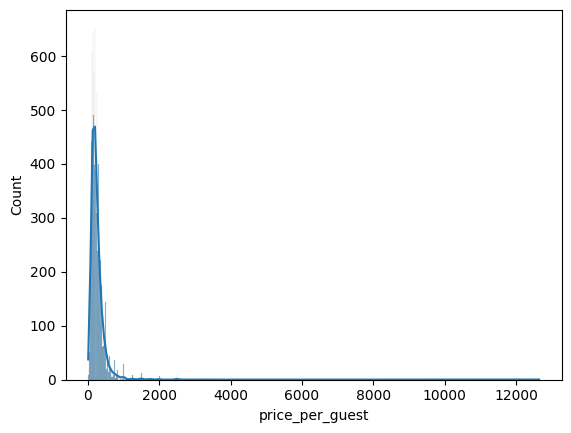

In [201]:
sns.histplot(df_active['price_per_guest'], kde=True)


<Axes: xlabel='log_price_per_guest', ylabel='Count'>

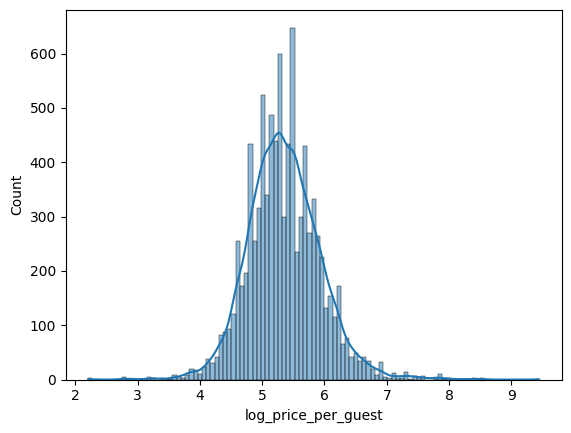

In [202]:
sns.histplot(df_active['log_price_per_guest'], kde=True)

In [203]:
model = smf.ols(
    """
    availability_30_pct ~ capacity 
    + log_price_per_guest 
    + bed_density 
    + C(city) 
    + C(room_type)
    """,
    data=df_active
).fit()

model_interaction = smf.ols(
    """
    availability_30_pct ~ capacity * C(city)
    + log_price_per_guest
    + bed_density
    + C(room_type)
    """,
    data=df_active
).fit()

model_interaction

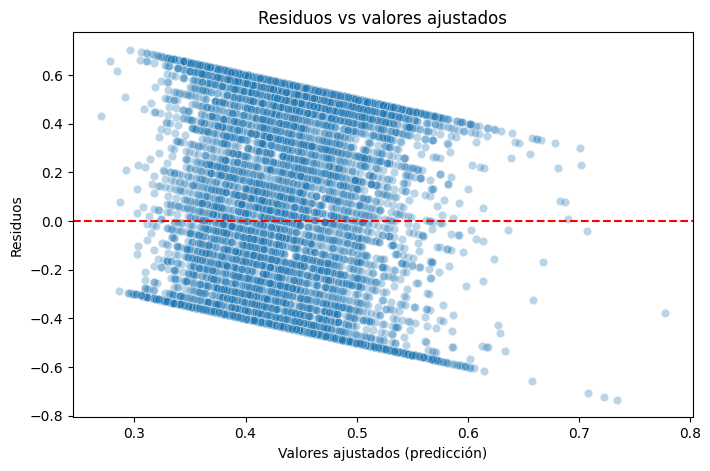

In [204]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=model_interaction.fittedvalues,
    y=model_interaction.resid,
    alpha=0.3
)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Valores ajustados (predicción)")
plt.ylabel("Residuos")
plt.title("Residuos vs valores ajustados")

plt.show()

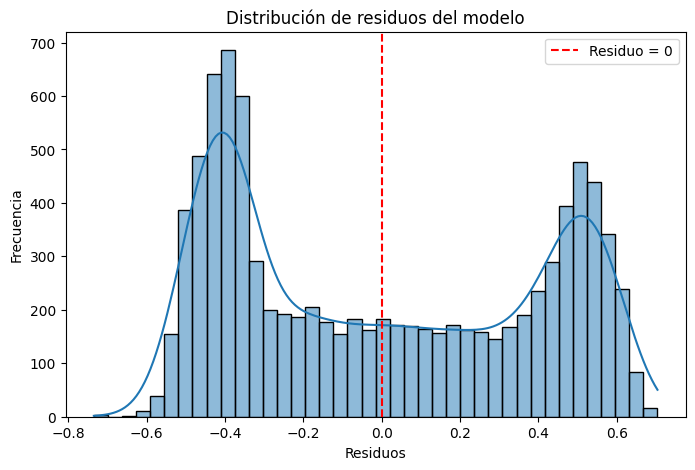

In [205]:
plt.figure(figsize=(8,5))

sns.histplot(
    model_interaction.resid,
    kde=True,
    bins=40
)

plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.title("Distribución de residuos del modelo")

plt.axvline(0, color='red', linestyle='--', label='Residuo = 0')

plt.legend()

plt.show()

<Axes: xlabel='city', ylabel='None'>

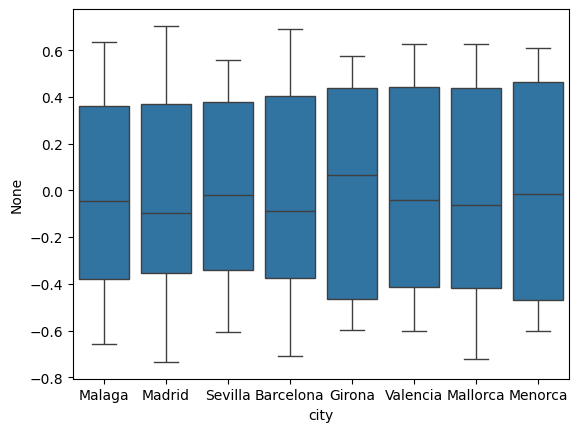

In [206]:
sns.boxplot(
    x='city',
    y=model_interaction.resid,
    data=df_active
)

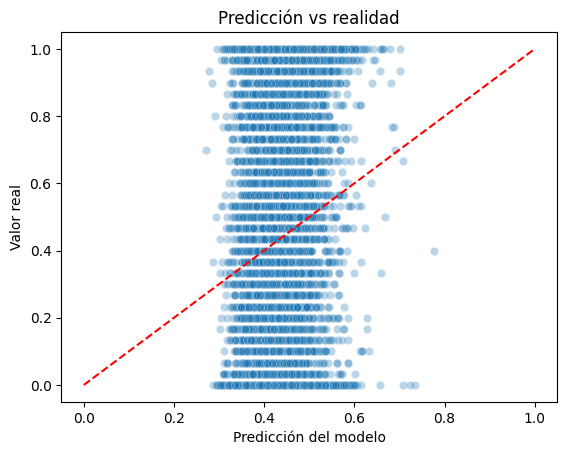

In [207]:
df_active['predicted'] = model_interaction.fittedvalues

sns.scatterplot(
    x='predicted',
    y='availability_30_pct',
    alpha=0.3,
    data=df_active
)

plt.plot([0,1],[0,1], color='red', linestyle='--')

plt.xlabel("Predicción del modelo")
plt.ylabel("Valor real")
plt.title("Predicción vs realidad")

plt.show()